In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Read the fused MUSICA–AURN–emission table
DATA_PATH = r'MUSICA_allvariables_CAMSAIR_CAMSv51_QFED_vsl.parquet'

df = pd.read_parquet(DATA_PATH)

# Convert MUSICA PM25 from kg m-3 to ug m-3
df['PM25'] = df['PM25'] * 1e9

print(f'Total count: {len(df)}')
print(df.head())

Total count: 595128
   Unnamed: 0        Date      Time          station  PM2.5 (Hourly measured)  \
0       27772  01/12/2018   5:00:00  Barnstaple A39                       0.0   
1       27773  01/12/2018   6:00:00  Barnstaple A39                       0.0   
2       27777  01/12/2018  10:00:00  Barnstaple A39                       0.0   
3       27789  01/12/2018  22:00:00  Barnstaple A39                       0.0   
4      246361  01/12/2018   2:00:00     Grangemouth                       0.0   

   nearest_grid_index   grid_lat  grid_lon            datetime  match_lat  \
0                6145  51.047636 -4.078403 2018-12-01 05:00:00  51.047636   
1                6145  51.047636 -4.078403 2018-12-01 06:00:00  51.047636   
2                6145  51.047636 -4.078403 2018-12-01 10:00:00  51.047636   
3                6145  51.047636 -4.078403 2018-12-01 22:00:00  51.047636   
4               13355  56.019011 -3.752133 2018-12-01 02:00:00  56.019011   

   ...  QFED_NO_bb QFED_BIGALD

In [3]:
df.columns.to_list()

['Unnamed: 0',
 'Date',
 'Time',
 'station',
 'PM2.5 (Hourly measured)',
 'nearest_grid_index',
 'grid_lat',
 'grid_lon',
 'datetime',
 'match_lat',
 'match_lon',
 'time',
 'ncol',
 'BURDENBCdn',
 'CLOUD',
 'FSDS',
 'CO',
 'NO',
 'NO2',
 'NO3',
 'NOX',
 'O3',
 'SO2',
 'T',
 'U',
 'V',
 'OMEGA500',
 'PBLH',
 'RELHUM',
 'PRECT',
 'PM25',
 'lat',
 'lon',
 'lev',
 'ilev',
 'CAMAIR_SO2_avi_sum',
 'CAMAIR_num_bc_a4_avi_sum',
 'CAMAIR_NO_avi_sum',
 'CAMAIR_NO2_avi_sum',
 'CAMAIR_bc_a4_avi_sum',
 'CAMSv51_HCOOH_sum',
 'CAMSv51_CH3CHO_sum',
 'CAMSv51_num_pom_a4_sum',
 'CAMSv51_C3H8_sum',
 'CAMSv51_BIGALK_sum',
 'CAMSv51_SVOC_sum',
 'CAMSv51_pom_a4_sum',
 'CAMSv51_bc_a4_sum',
 'CAMSv51_C2H2_sum',
 'CAMSv51_XYLENES_sum',
 'CAMSv51_MTERP_sum',
 'CAMSv51_TOLUENE_sum',
 'CAMSv51_C3H6_sum',
 'CAMSv51_CO_sum',
 'CAMSv51_MEK_sum',
 'CAMSv51_CH3OH_sum',
 'CAMSv51_num_bc_a4_sum',
 'CAMSv51_C2H5OH_sum',
 'CAMSv51_BIGENE_sum',
 'CAMSv51_C2H4_sum',
 'CAMSv51_ISOP_sum',
 'CAMSv51_C2H6_sum',
 'CAMSv51_IVOC_su

In [6]:
# Spearman rank correlations with the MUSICA bias
df = df.dropna(subset=['PM25', 'T', 'U', 'V',
                                         'PBLH', 'BURDENBCdn', 'CO',
                                         'NO', 'NO2', 'NO3', 'NOX', 'SO2'])

df['Bias'] = df['PM25'] - df['PM2.5 (Hourly measured)']

if 'U' in df.columns and 'V' in df.columns:
    df['WS'] = np.sqrt(df['U']**2 + df['V']**2)

exclude_cols = [
    'Unnamed: 0', 'Date', 'Time', 'station', 'nearest_grid_index', 'datetime', 
    'time', 'ncol', 'lev', 'ilev', 'grid_lat', 'grid_lon', 'match_lat', 'match_lon', 
    'lat', 'lon', 'site_id'
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
analysis_features = [col for col in numeric_cols if col not in exclude_cols]

print("--- Data cleaning complete ---")
print(f"Total columns: {df.shape[1]} | Features used in the correlation analysis: {len(analysis_features)}\n")

print("Computing the full Spearman rank correlation matrix...")
full_corr = df[analysis_features].corr(method='spearman')

# Rank all numeric variables by correlation with Bias
bias_corr = full_corr['Bias'].drop('Bias').to_frame(name='Spearman_r')

# Sort by absolute correlation so strong positive and negative associations rank together
bias_corr['Absolute_r'] = bias_corr['Spearman_r'].abs()
bias_corr_sorted = bias_corr.sort_values(by='Absolute_r', ascending=False)

print("\n======== Ranked correlations with Bias ========")
print(bias_corr_sorted[['Spearman_r']].to_string()) # full ranking; restrict with head() if a shorter preview is needed
print("====================================================\n")

--- Data cleaning complete ---
Total columns: 147 | Features used in the correlation analysis: 131

Computing the full Spearman rank correlation matrix...

======== Ranked correlations with Bias ========
                                         Spearman_r
PM2.5 (Hourly measured)                   -0.759526
PM25                                       0.432078
BURDENBCdn                                -0.420604
U                                          0.357675
CO                                        -0.330764
NOX                                       -0.288059
NO2                                       -0.281658
WS                                         0.270463
SO2                                       -0.269832
PBLH                                       0.220567
NO                                        -0.158192
O3                                         0.152876
V                                          0.125221
T                                          0.114351
CAMSv51_CH3CN_re

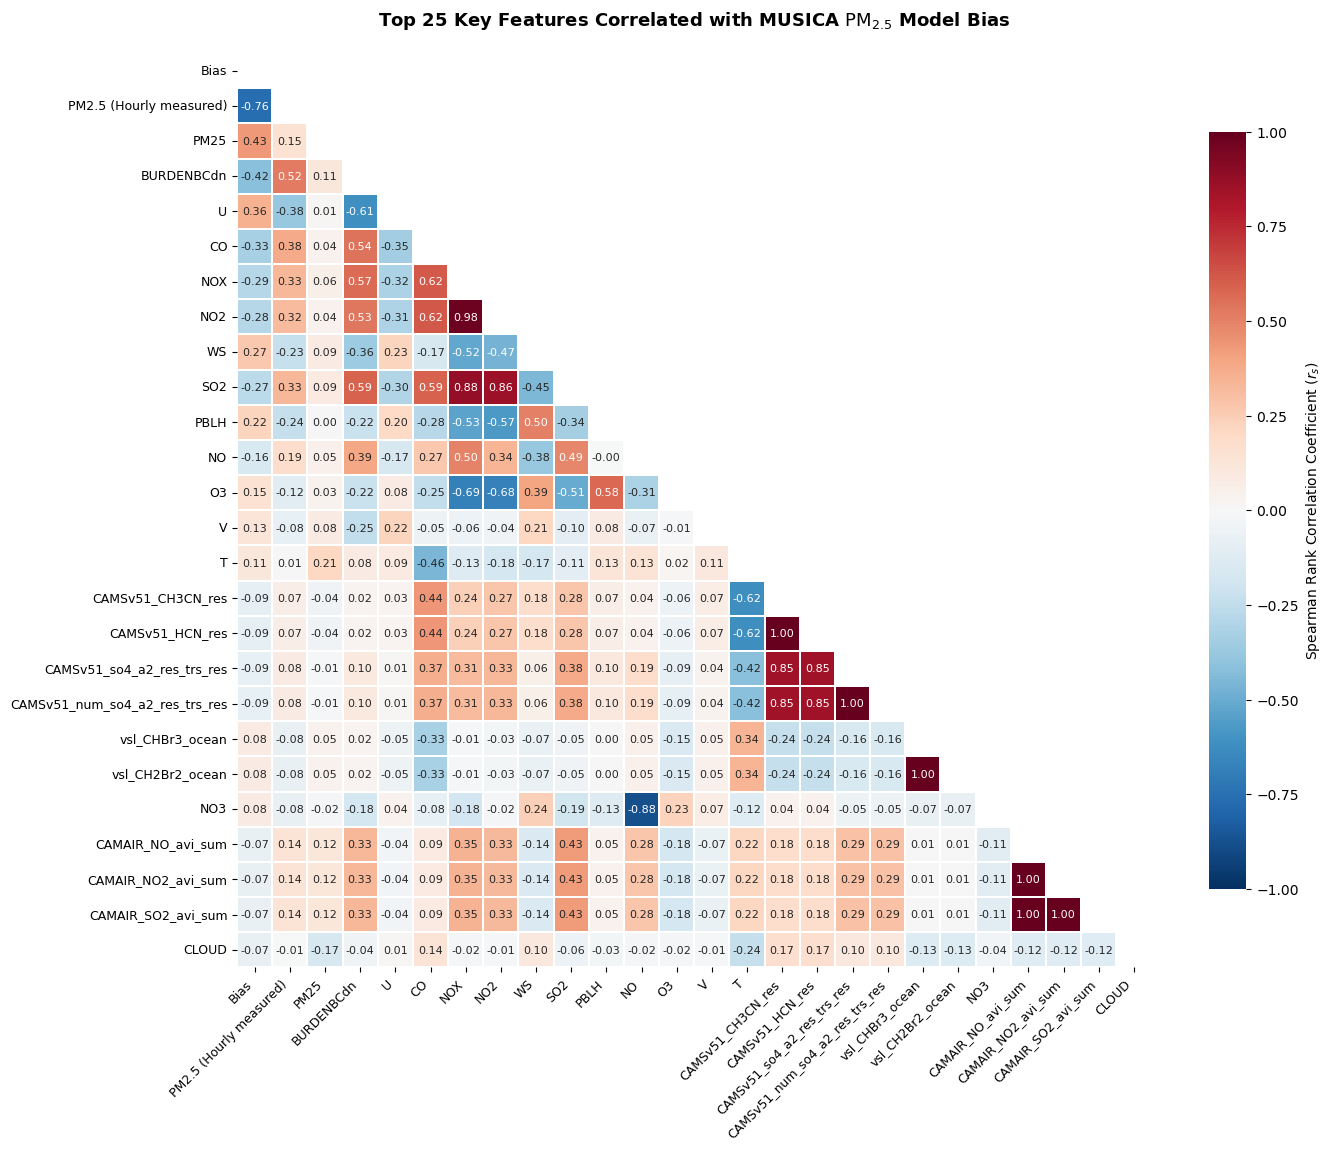

In [5]:
top_n = 25
top_features = ['Bias'] + bias_corr_sorted.index[:top_n].tolist()

plt.figure(figsize=(14, 12))

# Lower-triangle mask to hide redundant upper-triangle entries
mask = np.triu(np.ones_like(full_corr.loc[top_features, top_features], dtype=bool))

# Plot the lower-triangle correlation heatmap
sns.heatmap(full_corr.loc[top_features, top_features], 
            mask=mask, 
            annot=True,              # annotate cells
            fmt=".2f",               # two decimal places
            cmap='RdBu_r', 
            vmax=1.0, vmin=-1.0,     # colour scale fixed at [-1, 1]
            square=True,             # square cells
            linewidths=0.3,          # cell borders
            cbar_kws={"shrink": 0.75, "label": "Spearman Rank Correlation Coefficient ($r_s$)"},
            annot_kws={"size": 8})   # annotation font size

plt.title(f'Top {top_n} Key Features Correlated with MUSICA $\mathrm{{PM}}_{{2.5}}$ Model Bias', 
          fontsize=13, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Missing-value check after unit conversion
missing_counts = df.isnull().sum()
missing_percentages = 100 * df.isnull().sum() / len(df)
print(missing_counts)
print(missing_percentages)

Unnamed: 0                 0
Date                       0
Time                       0
station                    0
PM2.5 (Hourly measured)    0
                          ..
QFED_BIGENE_bb             0
vsl_CHBr3_ocean            0
vsl_CH2Br2_ocean           0
Bias                       0
WS                         0
Length: 147, dtype: int64
Unnamed: 0                 0.0
Date                       0.0
Time                       0.0
station                    0.0
PM2.5 (Hourly measured)    0.0
                          ... 
QFED_BIGENE_bb             0.0
vsl_CHBr3_ocean            0.0
vsl_CH2Br2_ocean           0.0
Bias                       0.0
WS                         0.0
Length: 147, dtype: float64


In [7]:
# Export the unit-converted table
df.to_csv(r'F:\Man\ERP\code\data\MUSICA_allvariables_CAMSAIR_CAMSv51_QFED_vsl_notnull_ugm3.csv')

In [8]:
# Summary statistics of the MUSICA bias
df_plot = df.copy()
df_plot['Bias'] = df_plot['PM25'] - df_plot['PM2.5 (Hourly measured)']

mean_bias = df_plot['Bias'].mean()
median_bias = df_plot['Bias'].median()
std_bias = df_plot['Bias'].std()
skew_bias = df_plot['Bias'].skew()

print("--- Bias summary statistics ---")
print(f"Mean bias: {mean_bias:.2f} μg/m³")
print(f"Median bias: {median_bias:.2f} μg/m³")
print(f"Standard deviation: {std_bias:.2f} μg/m³")
print(f"Skewness: {skew_bias:.2f} (positive values indicate a long overestimation tail)")

--- Bias summary statistics ---
Mean bias: -3.65 μg/m³
Median bias: -2.67 μg/m³
Standard deviation: 10.09 μg/m³
Skewness: -0.91 (positive values indicate a long overestimation tail)


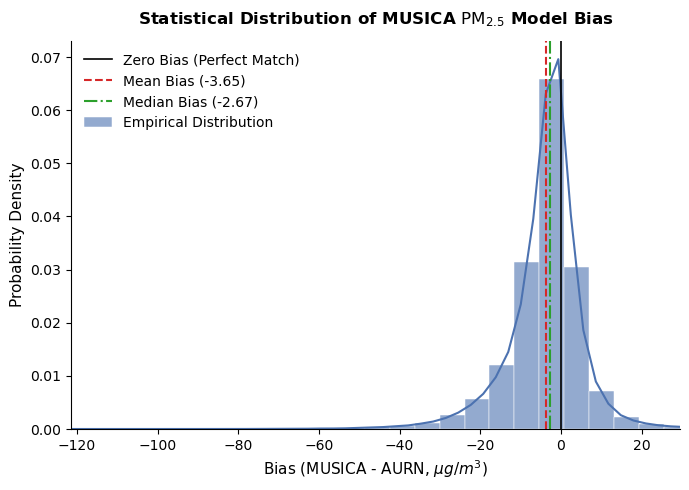

In [11]:
# Bias distribution
plt.figure(figsize=(7, 5))

# Histogram and kernel density estimate of Bias
sns.histplot(data=df_plot, x='Bias', kde=True, stat='density',
             color='#4c72b0', alpha=0.6, bins=100, edgecolor='white',
             label='Empirical Distribution')

# Reference lines at zero, the mean and the median
plt.axvline(0, color='black', linestyle='-', linewidth=1.2, label='Zero Bias (Perfect Match)')
plt.axvline(mean_bias, color='#d62728', linestyle='--', linewidth=1.5, 
            label=f'Mean Bias ({mean_bias:.2f})')
plt.axvline(median_bias, color='#2ca02c', linestyle='-.', linewidth=1.5, 
            label=f'Median Bias ({median_bias:.2f})')

plt.title('Statistical Distribution of MUSICA $\mathrm{PM}_{2.5}$ Model Bias', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Bias (MUSICA - AURN, $\mu g/m^3$)', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)

# Clip the x-axis so extreme outliers do not compress the main distribution
q_low, q_high = df_plot['Bias'].quantile([0.0001, 0.995])
plt.xlim(q_low, q_high)

plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)
sns.despine() 
plt.tight_layout()

plt.show()

In [10]:
# Station-mean bias for mapping
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

station_stats = df_plot.groupby('station').agg(
    Mean_Bias=('Bias', 'mean'),
    MAE=('Bias', lambda x: np.mean(np.abs(x))),
    RMSE=('Bias', lambda x: np.sqrt(np.mean(x**2))),
    Latitude=('grid_lat', 'mean'),   # retained for spatial mapping
    Longitude=('grid_lon', 'mean'), # retained for spatial mapping
    Sample_Size=('Bias', 'count')
).reset_index()

print(station_stats.sort_values(by='Mean_Bias').to_string(index=False, formatters={
    'Mean_Bias': '{:,.2f}'.format, 'MAE': '{:,.2f}'.format, 'RMSE': '{:,.2f}'.format,
    'Latitude': '{:,.4f}'.format, 'Longitude': '{:,.4f}'.format
}))

                         station Mean_Bias  MAE  RMSE Latitude Longitude  Sample_Size
         London Marylebone Road      -8.38 9.93 13.14  51.5399   -0.1337         7790
               Chatham Roadside      -8.06 9.89 14.23  51.3735    0.5595         8414
        Sheffield Barnsley Road      -7.74 9.67 14.92  53.3668   -1.4696         8205
                 Sandy Roadside      -7.09 8.97 12.77  52.0968   -0.3194         5446
      Leamington Spa Rugby Road      -6.32 8.48 11.77  52.3189   -1.5620         6479
               Swansea Roadside      -5.87 9.21 12.62  51.6202   -3.9663         8085
      Birmingham A4540 Roadside      -5.84 8.00 11.46  52.4916   -1.8907         8230
                   Wigan Centre      -5.59 7.90 11.71  53.5805   -2.6717         6767
                Southend-on-Sea      -5.54 8.12 12.50  51.5631    0.6287         5598
     Sheffield Devonshire Green      -5.43 8.01 12.82  53.3668   -1.4696         7918
                     Portsmouth      -5.41 8.13 11.59 

In [11]:
station_stats.to_csv(r'F:\Man\ERP\code\data\station_bias_stats_ugm3.csv')

In [12]:
# Latitudinal and longitudinal trends in Bias
p_lat_r, p_lat_p = pearsonr(df_plot['grid_lat'], df_plot['Bias'])
s_lat_r, s_lat_p = spearmanr(df_plot['grid_lat'], df_plot['Bias'])

p_lon_r, p_lon_p = pearsonr(df_plot['grid_lon'], df_plot['Bias'])
s_lon_r, s_lon_p = spearmanr(df_plot['grid_lon'], df_plot['Bias'])

print(f"Latitude vs Bias -> Pearson r: {p_lat_r:.3f} (p={p_lat_p:.3e}), Spearman r: {s_lat_r:.3f}")
print(f"Longitude vs Bias -> Pearson r: {p_lon_r:.3f} (p={p_lon_p:.3e}), Spearman r: {s_lon_r:.3f}")

Latitude vs Bias -> Pearson r: 0.053 (p=0.000e+00), Spearman r: 0.052
Longitude vs Bias -> Pearson r: -0.079 (p=0.000e+00), Spearman r: -0.082


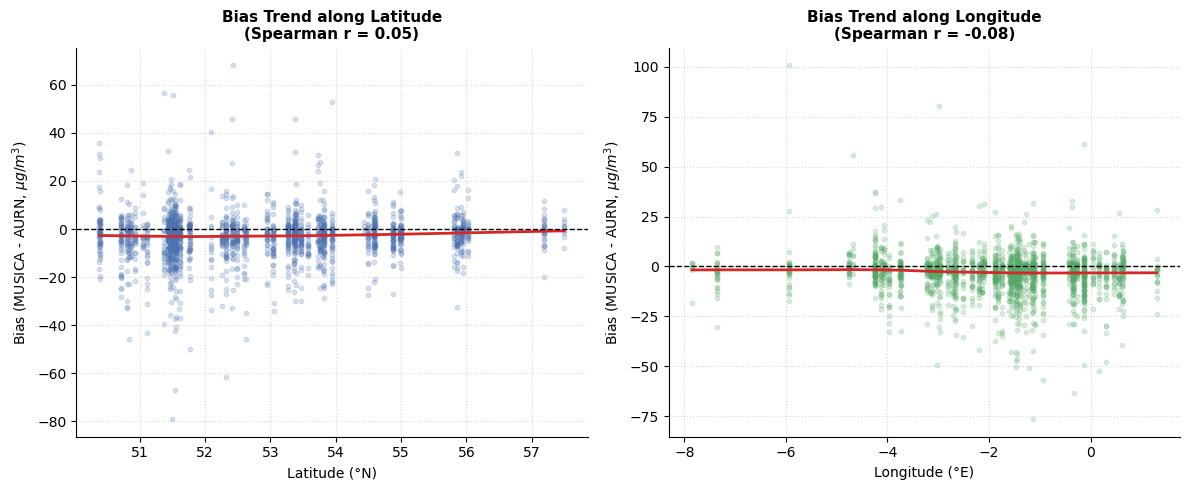

In [13]:
# Scatter of Bias against latitude and longitude
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Latitude
sns.regplot(data=df_plot.sample(min(2000, len(df_plot))), x='grid_lat', y='Bias', 
            ax=axes[0], lowess=True,
            scatter_kws={'alpha': 0.2, 'color': '#4c72b0', 's': 10},
            line_kws={'color': '#d62728', 'linewidth': 2, 'label': 'LOWESS Trend'})
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'Bias Trend along Latitude\n(Spearman r = {s_lat_r:.2f})', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Latitude (°N)')
axes[0].set_ylabel('Bias (MUSICA - AURN, $\mu g/m^3$)')
axes[0].grid(axis='both', linestyle=':', alpha=0.5)

# Longitude
sns.regplot(data=df_plot.sample(min(2000, len(df_plot))), x='grid_lon', y='Bias', 
            ax=axes[1], lowess=True,
            scatter_kws={'alpha': 0.2, 'color': '#55a868', 's': 10},
            line_kws={'color': '#d62728', 'linewidth': 2, 'label': 'LOWESS Trend'})
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'Bias Trend along Longitude\n(Spearman r = {s_lon_r:.2f})', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Bias (MUSICA - AURN, $\mu g/m^3$)')
axes[1].grid(axis='both', linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

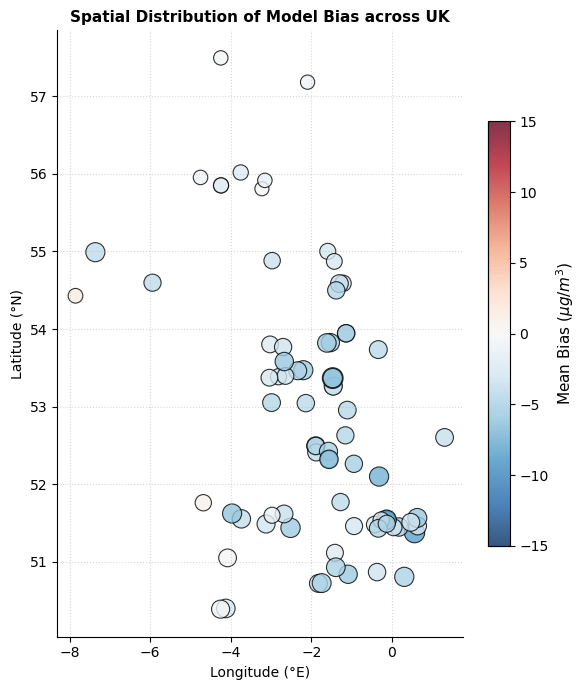

In [14]:
# Mapped station-mean bias
plt.figure(figsize=(6, 7))

sc = plt.scatter(station_stats['Longitude'], station_stats['Latitude'], 
                 c=station_stats['Mean_Bias'], cmap='RdBu_r', vmin=-15, vmax=15,
                 s=station_stats['RMSE']*15, alpha=0.8, edgecolor='black', linewidth=0.8)

cbar = plt.colorbar(sc, shrink=0.7)
cbar.set_label('Mean Bias ($\mu g/m^3$)', fontsize=11)
plt.title('Spatial Distribution of Model Bias across UK', fontsize=11, fontweight='bold')
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.grid(linestyle=':', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

E:\AIProjects\Cache\Temp\ipykernel_8320\4198040658.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DayOfWeek', y='Bias', ax=axes[1],


E:\AIProjects\Cache\Temp\ipykernel_8320\4198040658.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(day_labels)


E:\AIProjects\Cache\Temp\ipykernel_8320\4198040658.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(month_labels, rotation=30) # rotate tick labels to avoid overlap


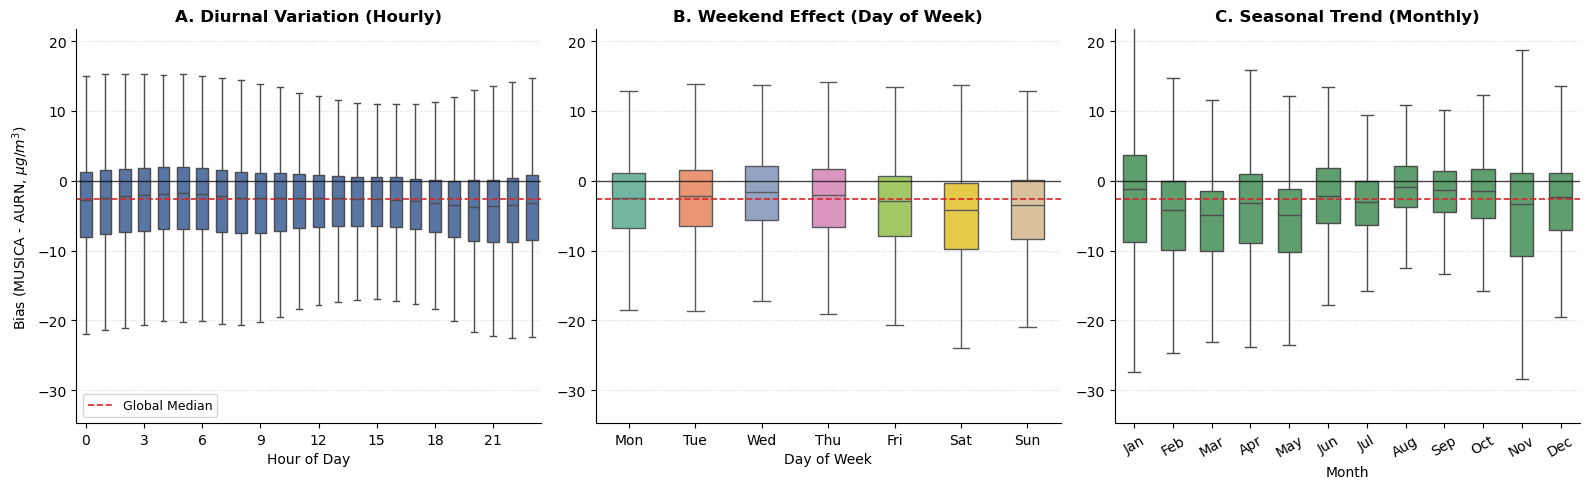

In [ ]:
df['Hour'] = df['datetime'].dt.hour
df['DayOfWeek'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Month'] = df['datetime'].dt.month

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Diurnal variation of Bias
sns.boxplot(data=df, x='Hour', y='Bias', ax=axes[0], 
            color='#4c72b0', width=0.6, showfliers=False)
axes[0].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
axes[0].axhline(df['Bias'].median(), color='#d62728', linestyle='--', linewidth=1.2, label='Global Median')
axes[0].set_title('A. Diurnal Variation (Hourly)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Bias (MUSICA - AURN, $\mu g/m^3$)')
axes[0].set_xticks(range(0, 24, 3)) # tick every three hours
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

# Day-of-week variation of Bias
sns.boxplot(data=df, x='DayOfWeek', y='Bias', ax=axes[1], 
            palette='Set2', width=0.5, showfliers=False)
axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
axes[1].axhline(df['Bias'].median(), color='#d62728', linestyle='--', linewidth=1.2)
axes[1].set_title('B. Weekend Effect (Day of Week)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('') # shared y-axis; leave the label blank
axes[1].set_xticklabels(day_labels)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)

# Monthly variation of Bias
sns.boxplot(data=df, x='Month', y='Bias', ax=axes[2], 
            color='#55a868', width=0.6, showfliers=False)
axes[2].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.7)
axes[2].axhline(df['Bias'].median(), color='#d62728', linestyle='--', linewidth=1.2)
axes[2].set_title('C. Seasonal Trend (Monthly)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('')
axes[2].set_xticklabels(month_labels, rotation=30) # rotate tick labels to avoid overlap
axes[2].grid(axis='y', linestyle=':', alpha=0.5)

y_min = df['Bias'].quantile(0.01)
y_max = df['Bias'].quantile(0.99)
for ax in axes:
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc='lower left', frameon=True, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# Wind speed from the U and V components
df['WS'] = np.sqrt(df['U']**2 + df['V']**2)

# Meteorological wind direction (degrees clockwise from north)
df['WD'] = np.degrees(np.arctan2(df['U'], df['V']))
df.loc[df['WD'] < 0, 'WD'] += 360

print("--- STEP 2: Spearman correlations between Bias and meteorological variables ---")
met_vars = ['PBLH', 'T', 'WS', 'U', 'V']
for var in met_vars:
    r_val, p_val = spearmanr(df[var], df['Bias'])
    print(f"Bias vs {var:4s} -> Spearman r = {r_val:6.3f} (p = {p_val:.3e})")

--- STEP 2: Spearman correlations between Bias and meteorological variables ---
Bias vs PBLH -> Spearman r =  0.221 (p = 0.000e+00)
Bias vs T    -> Spearman r =  0.114 (p = 0.000e+00)
Bias vs WS   -> Spearman r =  0.270 (p = 0.000e+00)
Bias vs U    -> Spearman r =  0.358 (p = 0.000e+00)
Bias vs V    -> Spearman r =  0.125 (p = 0.000e+00)


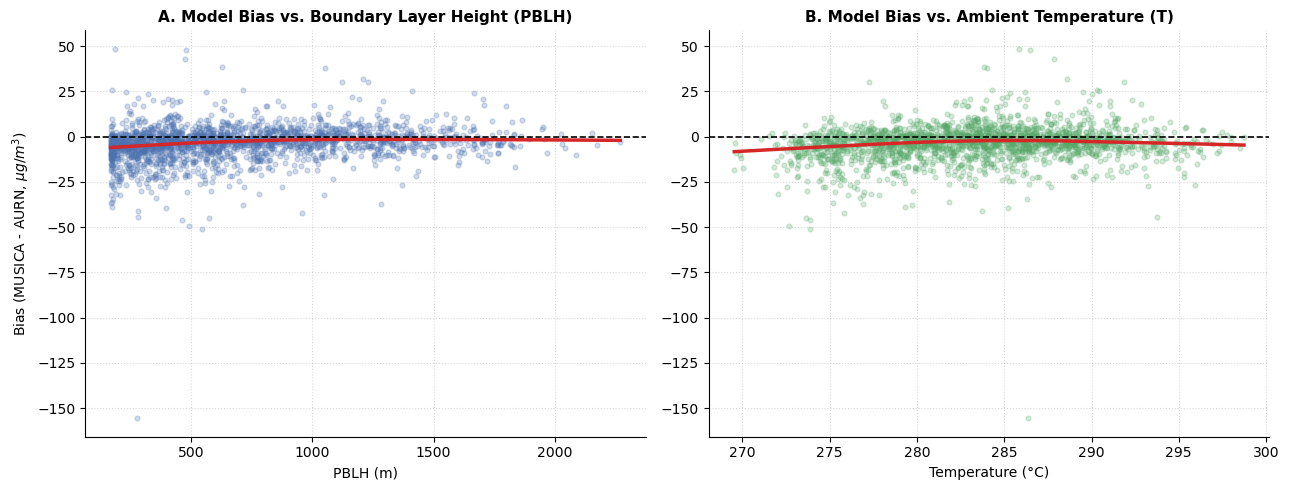

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df_sub = df.sample(min(2000, len(df)), random_state=42)

# Bias against planetary boundary-layer height
sns.regplot(data=df_sub, x='PBLH', y='Bias', ax=axes[0], lowess=True,
            scatter_kws={'alpha': 0.25, 'color': '#4c72b0', 's': 12},
            line_kws={'color': '#d62728', 'linewidth': 2.5, 'label': 'LOWESS Trend'})
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[0].set_title('A. Model Bias vs. Boundary Layer Height (PBLH)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('PBLH (m)')
axes[0].set_ylabel('Bias (MUSICA - AURN, $\mu g/m^3$)')
axes[0].grid(linestyle=':', alpha=0.5)

# Bias against temperature
sns.regplot(data=df_sub, x='T', y='Bias', ax=axes[1], lowess=True,
            scatter_kws={'alpha': 0.25, 'color': '#55a868', 's': 12},
            line_kws={'color': '#d62728', 'linewidth': 2.5})
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('B. Model Bias vs. Ambient Temperature (T)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('') # shared y-axis
axes[1].grid(linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

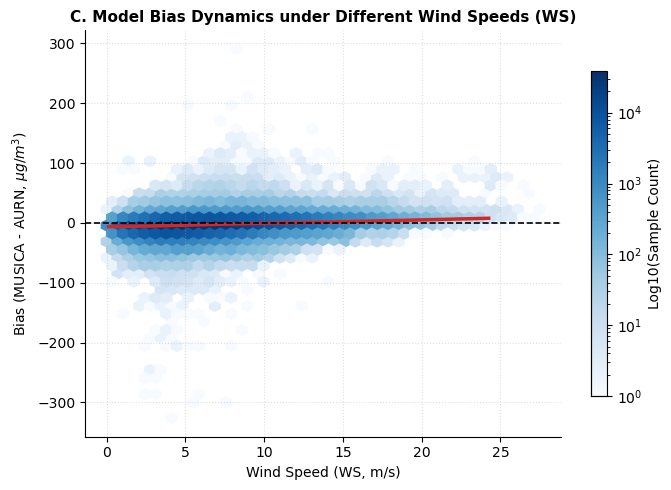

In [18]:
# Relationship between wind speed and Bias
plt.figure(figsize=(7, 5))

# Hexbin density of wind speed versus Bias
hb = plt.hexbin(df['WS'], df['Bias'], gridsize=40, 
                cmap='Blues', mincnt=1, bins='log')
# Overlay a LOWESS trend
sns.regplot(data=df_sub, x='WS', y='Bias', scatter=False, lowess=True, 
            line_kws={'color': '#d62728', 'linewidth': 2.5, 'label': 'LOWESS Trend'})

plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
cb = plt.colorbar(hb, shrink=0.8)
cb.set_label('Log10(Sample Count)')
plt.title('C. Model Bias Dynamics under Different Wind Speeds (WS)', fontsize=11, fontweight='bold')
plt.xlabel('Wind Speed (WS, m/s)')
plt.ylabel('Bias (MUSICA - AURN, $\mu g/m^3$)')
plt.grid(linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

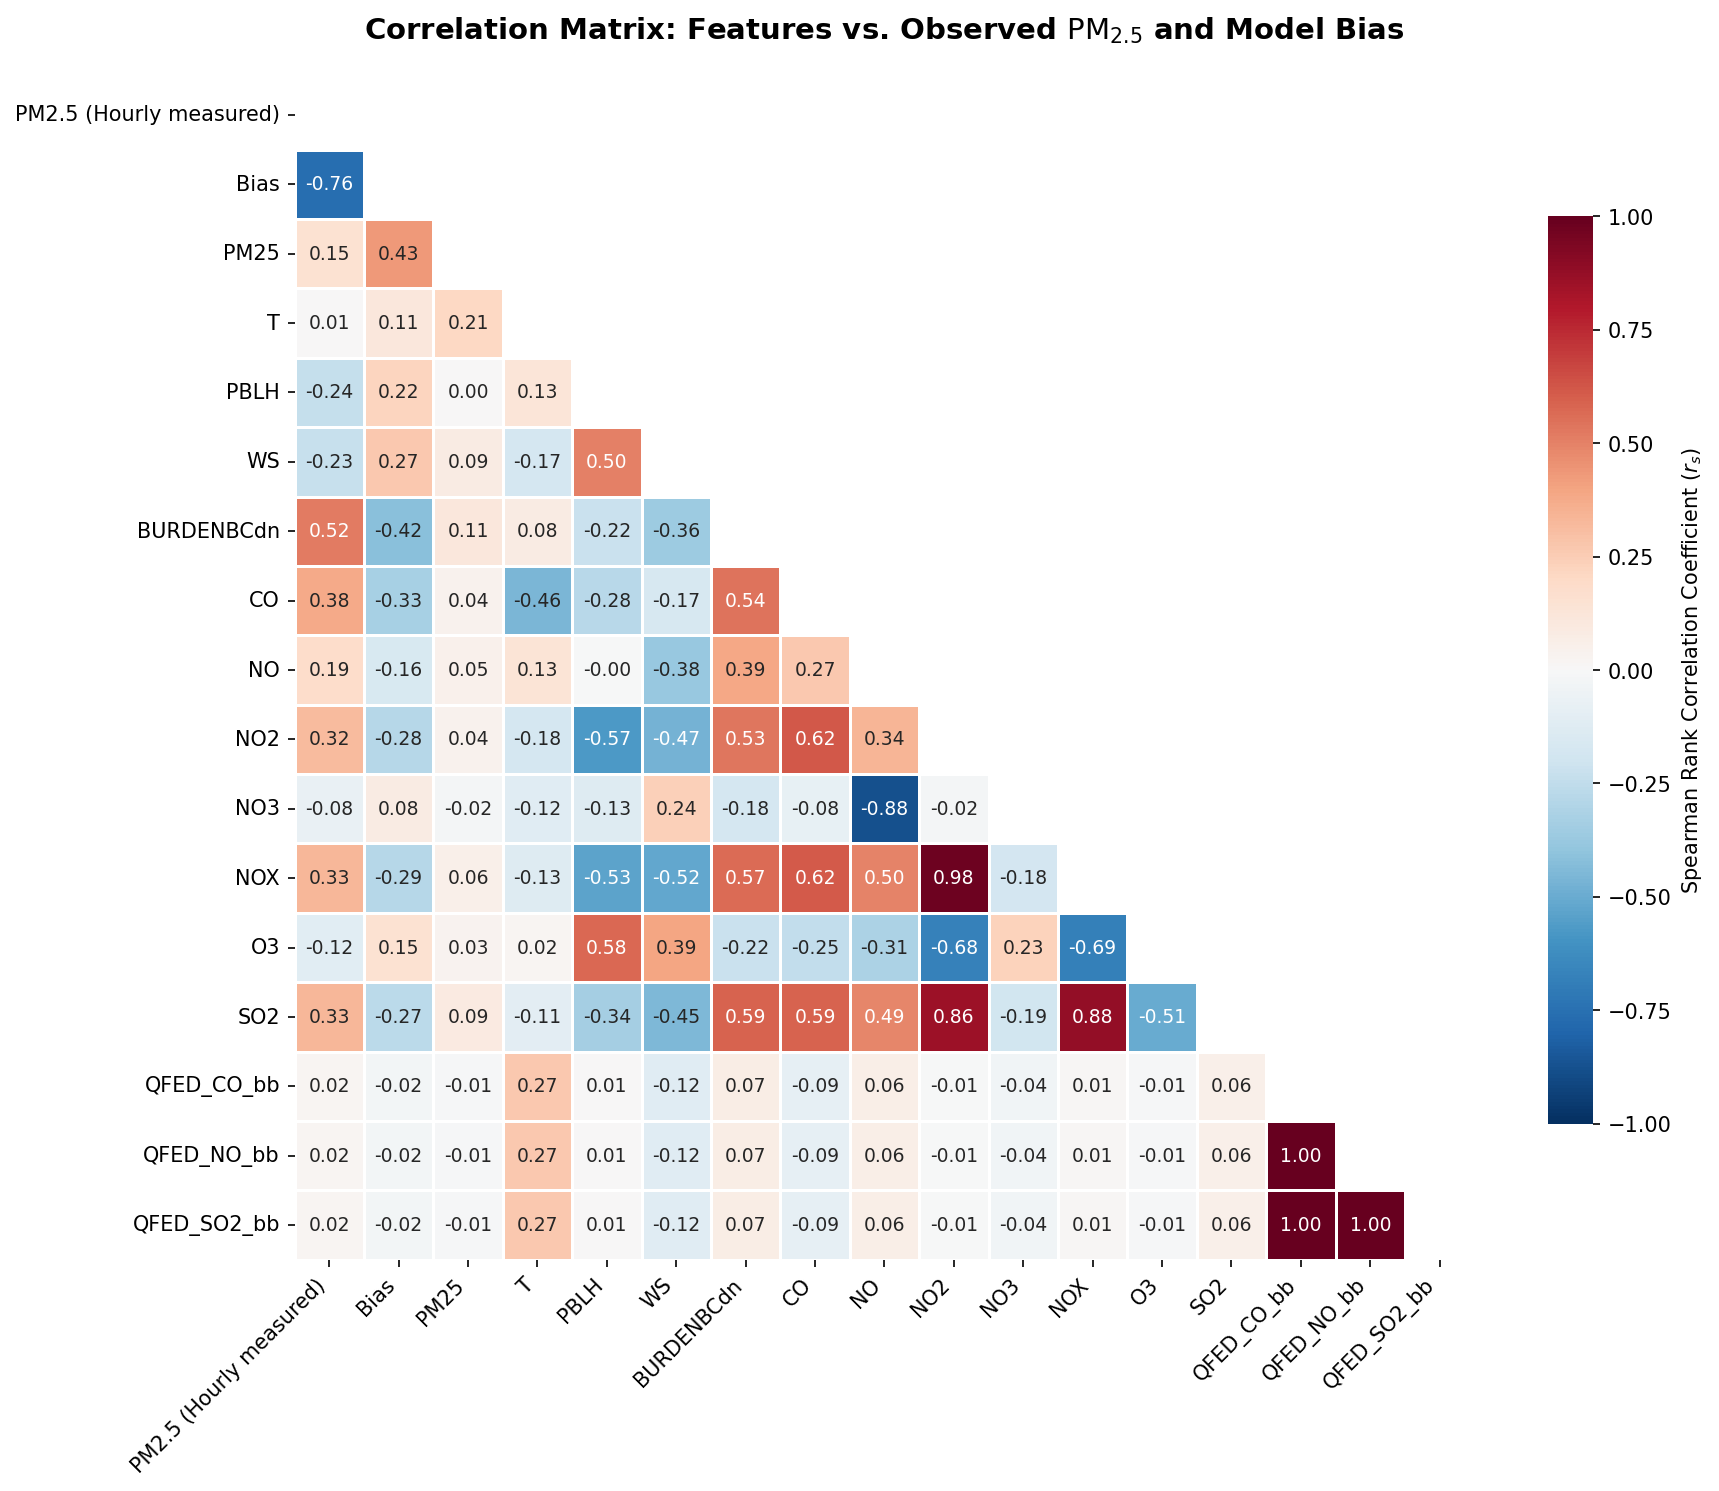

In [ ]:
# Derived meteorological quantities
if 'U' in df.columns and 'V' in df.columns:
    df['WS'] = np.sqrt(df['U']**2 + df['V']**2)

# Select a compact predictor subset for the correlation heatmap; omit identifier columns
target_and_bias = ['PM2.5 (Hourly measured)', 'Bias', 'PM25']

met_features = ['T', 'PBLH', 'WS', 'BURDENBCdn'] if 'WS' in df.columns else ['T', 'PBLH', 'U', 'V', 'BURDENBCdn']

# Representative chemical precursors and QFED biomass-burning tracers
chem_features = [col for col in ['CO', 'NO', 'NO2', 'NO3', 'NOX', 'O3', 'SO2'] if col in df.columns]
qfed_features = [col for col in ['QFED_CO_bb', 'QFED_NO_bb', 'QFED_SO2_bb'] if col in df.columns]

# Combine the selected analysis columns
analysis_cols = target_and_bias + met_features + chem_features + qfed_features

# Keep only columns present in the working table
analysis_cols = [col for col in analysis_cols if col in df.columns]

# ==============================================================================
# Spearman correlation matrix for the selected variables
# ==============================================================================
corr_matrix = df[analysis_cols].corr(method='spearman')

# ==============================================================================
# Lower-triangle heatmap of the Spearman matrix
# ==============================================================================
plt.figure(figsize=(12, 10))

# Lower-triangle mask to hide redundant upper-triangle entries
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
# Diverging RdBu_r scale: red for positive, blue for negative, white near zero
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,              # annotate cells
            fmt=".2f",               # two decimal places
            cmap='RdBu_r', 
            vmax=1.0, vmin=-1.0,     # colour scale fixed at [-1, 1]
            square=True,             # square cells
            linewidths=0.5,          # cell-border width
            cbar_kws={"shrink": 0.75, "label": "Spearman Rank Correlation Coefficient ($r_s$)"}, # colour-bar formatting
            annot_kws={"size": 9})   # annotation font size

# Figure annotations
plt.title('Correlation Matrix: Features vs. Observed $\mathrm{PM}_{2.5}$ and Model Bias', 
          fontsize=14, fontweight='bold', pad=20)

# Rotate axis tick labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


In [20]:
# Assemble the modelling feature set
df['datetime'] = pd.to_datetime(df['datetime'])
df['Hour'] = df['datetime'].dt.hour
df['Month'] = df['datetime'].dt.month
df['DayOfWeek'] = df['datetime'].dt.dayofweek

# Aggregate sectoral emission fields
# Aviation emissions
avi_cols = [c for c in df.columns if 'avi' in c]
if avi_cols:
    df['CAMAIR_Total_Aviation'] = df[avi_cols].sum(axis=1)

# Traffic and residential emissions
traffic_cols = [c for c in df.columns if ('_trs' in c) or ('_tro' in c)]
if traffic_cols:
    df['CAMSv51_Total_Traffic_Residential'] = df[traffic_cols].sum(axis=1)

# Industrial and energy emissions
ind_cols = [c for c in df.columns if ('_ene' in c) or ('_ind' in c)]
if ind_cols:
    df['CAMSv51_Total_Industrial'] = df[ind_cols].sum(axis=1)

features_to_keep = [
    # Target and ground-truth columns retained for later splits
    'PM2.5 (Hourly measured)', 'Bias',
    
    # Station and time identifiers; excluded from model inputs
    'datetime', 'station', 'site_id', 'latitude', 'longitude', 
    
    # Cyclical time features
    'Hour', 'Month', 'DayOfWeek',
    
    # MUSICA PM2.5 and selected meteorological and chemical fields
    'PM25', 'T', 'U', 'V', 'PBLH', 'BURDENBCdn', 'CO', 'NO', 'NO2', 'NO3', 'NOX', 'O3', 'SO2',
    
    # Aggregated CAMS sectoral emission features
    'CAMAIR_Total_Aviation', 'CAMSv51_Total_Traffic_Residential', 'CAMSv51_Total_Industrial',
    'CAMSv51_IVOC_sum', 'CAMSv51_CO_sum', 'CAMSv51_SO2_sum', 'CAMSv51_NH3_sum', 'CAMSv51_NO_sum', 'CAMSv51_bc_a4_sum',
    'CAMSv51_CH2O_sum',
    
    # Representative QFED biomass-burning tracers
    'QFED_XYLENES_bb', 'QFED_HYAC_bb', 'QFED_TERPENES_bb', 'QFED_DMS_bb', 'QFED_C3H8_bb',  'QFED_BENZENE_bb',  'QFED_TOLUENE_bb',
     'QFED_HCN_bb'
]

actual_features_to_keep = [col for col in features_to_keep if col in df.columns]

filtered_df = df[actual_features_to_keep].copy()

meta_cols = ['datetime', 'station', 'site_id', 'latitude', 'longitude']
ml_train_features = [c for c in filtered_df.columns if c not in meta_cols]

print("--- Spatiotemporal ML Dataset Feature Extraction Complete ---")
print(f"Original Raw DataFrame: {len(df.columns)} columns")
print(f"Retained Spatiotemporal Dataset: {len(filtered_df.columns)} columns")
print(f"Pure ML Training Feature Input Count: {len(ml_train_features)} variables")
print(f"Retained ML Features: {ml_train_features}")




--- Spatiotemporal ML Dataset Feature Extraction Complete ---
Original Raw DataFrame: 154 columns
Retained Spatiotemporal Dataset: 38 columns
Pure ML Training Feature Input Count: 36 variables
Retained ML Features: ['PM2.5 (Hourly measured)', 'Bias', 'Hour', 'Month', 'DayOfWeek', 'PM25', 'T', 'U', 'V', 'PBLH', 'BURDENBCdn', 'CO', 'NO', 'NO2', 'NO3', 'NOX', 'O3', 'SO2', 'CAMAIR_Total_Aviation', 'CAMSv51_Total_Traffic_Residential', 'CAMSv51_Total_Industrial', 'CAMSv51_IVOC_sum', 'CAMSv51_CO_sum', 'CAMSv51_SO2_sum', 'CAMSv51_NH3_sum', 'CAMSv51_NO_sum', 'CAMSv51_bc_a4_sum', 'CAMSv51_CH2O_sum', 'QFED_XYLENES_bb', 'QFED_HYAC_bb', 'QFED_TERPENES_bb', 'QFED_DMS_bb', 'QFED_C3H8_bb', 'QFED_BENZENE_bb', 'QFED_TOLUENE_bb', 'QFED_HCN_bb']


In [ ]:
# Write the extracted modelling table
filtered_df.to_csv(r'Extracted_features_dataset.csv')